# Credit Risk Scoring: EDA & Modeling

**Dataset:** [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit) (Kaggle), ~150,000 anonymized consumer credit records.

**Business problem:** Given an applicant's credit profile, estimate the probability they will experience serious delinquency (90+ days past due) within the next two years, then translate that probability into a scaled credit score and risk tier a lending team can act on.

**Target:** `SeriousDlqin2yrs` (1 = defaulted, 0 = did not)

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_prep import load_raw, clean_and_engineer, RAW_FEATURES, TARGET

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

raw = load_raw("../data/raw/cs-training.csv")
raw.shape

(150000, 11)

## 1. First look at the raw data

In [2]:
raw.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
raw[TARGET].value_counts(normalize=True).rename("share").to_frame()

,share
SeriousDlqin2yrs,
0,0.93316
1,0.06684


Base rate is ~6.7%, so the target is imbalanced. That rules out accuracy as a metric (predicting "no default" for everyone is 93% accurate), so the models are evaluated with AUC, KS and PR-AUC instead. I tried class weighting early on and dropped it: it didn't improve ranking and it inflated every predicted PD, which breaks the score scale and any expected-loss math.

In [4]:
missing = raw.isna().mean().sort_values(ascending=False)
missing[missing > 0].rename("pct_missing").to_frame()

,pct_missing
MonthlyIncome,0.198207
NumberOfDependents,0.026160


`MonthlyIncome` is missing for ~20% of records and `NumberOfDependents` for ~2.6%. Both are imputed in `clean_and_engineer`, with a `_missing` flag kept as its own feature since not reporting income can itself be predictive. The imputation values are learned on the training split only.

In [5]:
raw[RAW_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0
NumberOfDependents,146076.0,0.757222,1.115086,0.0,0.000000,0.000000,1.000000,20.0


A few columns have implausible maxima. `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` both have values in the thousands (they should sit under ~2), and the "times past due" columns have a cluster of records at 96/98, which are data-entry codes rather than real counts. These are capped in `src/data_prep.py` instead of dropped, so the rest of each record is kept.

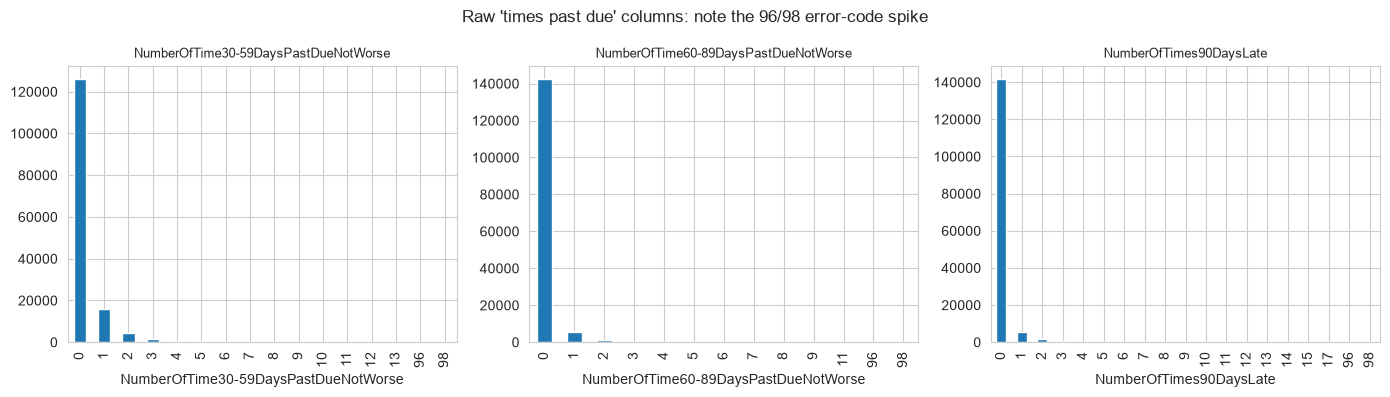

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfTimes90DaysLate"]):
    raw[col].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(col, fontsize=9)
fig.suptitle("Raw 'times past due' columns: note the 96/98 error-code spike")
fig.tight_layout()
plt.show()

## 2. Cleaning & feature engineering

In [7]:
clean = clean_and_engineer(raw)
clean.shape

(150000, 21)

In [8]:
clean[["RevolvingUtilization_capped", "DebtRatio", "TotalTimesPastDue", "HasPastDueHistory", "IncomePerDependent"]].describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilization_capped,150000.0,0.322328,0.356769,0.0,0.029867,0.154181,0.559046,1.366269e+00
DebtRatio,150000.0,325.217939,955.301614,0.0,0.175074,0.366508,0.868254,6.186010e+03
TotalTimesPastDue,150000.0,0.429047,1.283798,0.0,0.000000,0.000000,0.000000,1.900000e+01
HasPastDueHistory,150000.0,0.202420,0.401805,0.0,0.000000,0.000000,0.000000,1.000000e+00
IncomePerDependent,150000.0,4589.119181,7974.493101,0.0,2151.000000,4000.000000,5400.000000,1.794060e+06


## 3. What separates defaulters from non-defaulters?

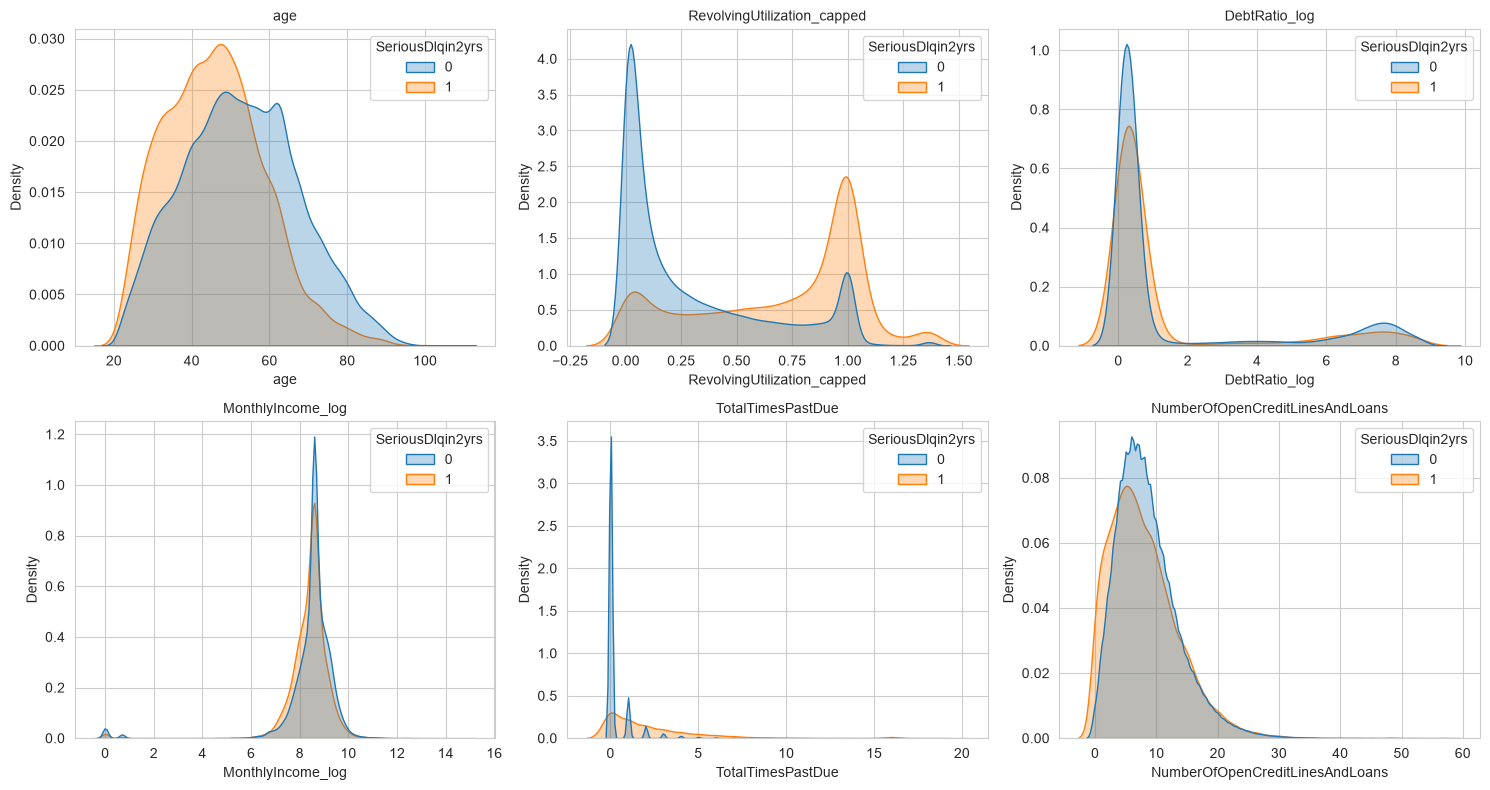

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feats = ["age", "RevolvingUtilization_capped", "DebtRatio_log", "MonthlyIncome_log",
         "TotalTimesPastDue", "NumberOfOpenCreditLinesAndLoans"]
for ax, feat in zip(axes.ravel(), feats):
    sns.kdeplot(data=clean, x=feat, hue=TARGET, common_norm=False, ax=ax, fill=True, alpha=0.3)
    ax.set_title(feat, fontsize=10)
fig.tight_layout()
plt.show()

Delinquency history and utilization separate the two groups clearly, as expected since they are the classic risk signals. Age (younger borrowers default more) and income show a weaker but real signal.

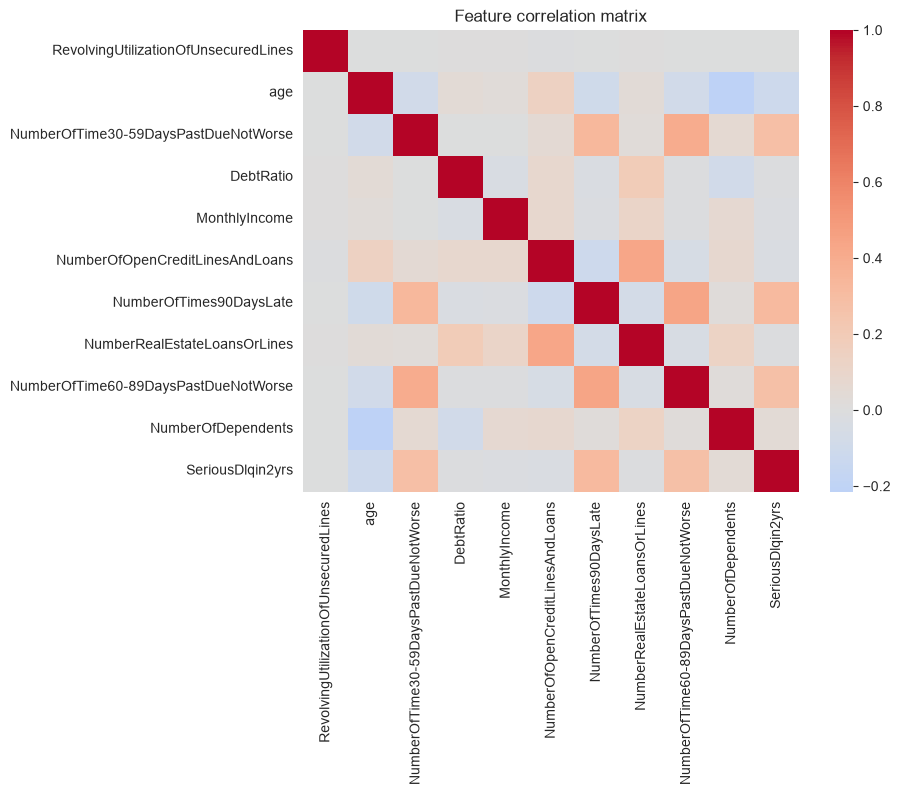

In [10]:
corr = clean[RAW_FEATURES + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Feature correlation matrix")
plt.show()

No pair of raw features is collinear enough to justify dropping one. The past-due columns are the closest, which is why they are also summed into `TotalTimesPastDue` while being kept individually.

## 4. Modeling, evaluation, and scoring

The training pipeline lives in `src/train.py`: a logistic regression baseline and XGBoost, evaluated on a held-out 25% test split with ROC-AUC, PR-AUC, KS and Gini, plus Brier score and mean predicted PD to check calibration. Results are loaded here from `models/metrics.json`; run `python -m src.train` from the project root to regenerate them.

In [11]:
import json
with open("../models/metrics.json") as f:
    metrics = json.load(f)
pd.DataFrame(metrics).T

,roc_auc,pr_auc,ks_statistic,gini,brier_score,mean_predicted_pd,observed_default_rate,top_decile_capture_rate
logistic_regression,0.8609,0.3861,0.5639,0.7219,0.0498,0.0665,0.0668,NaN
xgboost,0.8694,0.4075,0.5778,0.7387,0.0486,0.0667,0.0668,0.5591


XGBoost beats the logistic regression on every metric, but not by much. That matches how the two usually compare: the regression is a strong, fully auditable baseline (its coefficients can be read directly), and the boosted model adds a modest lift plus better ranking at the risky end (KS, top-decile capture). Both are well calibrated: mean predicted PD matches the observed default rate.

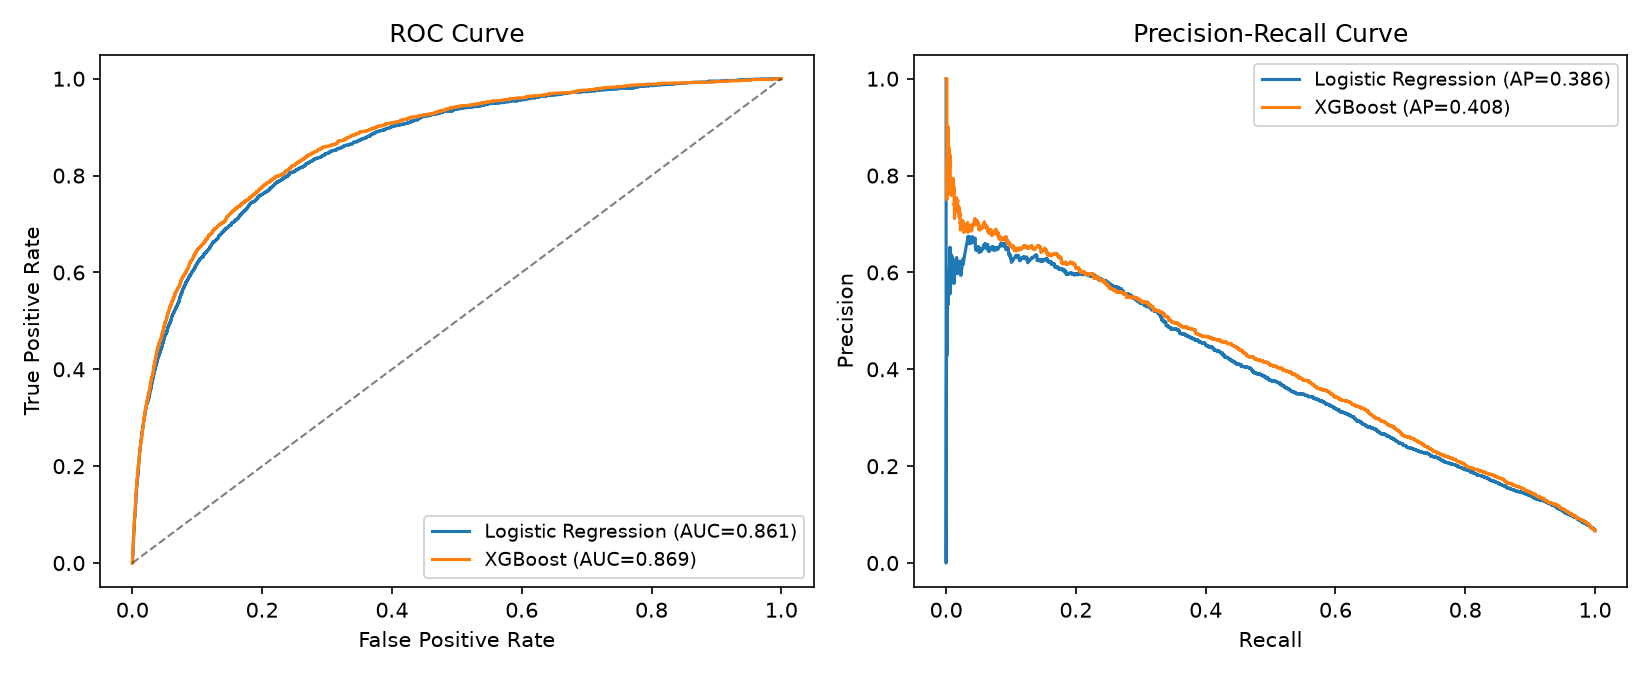

In [12]:
from IPython.display import Image
Image("../reports/figures/roc_pr_curves.png")

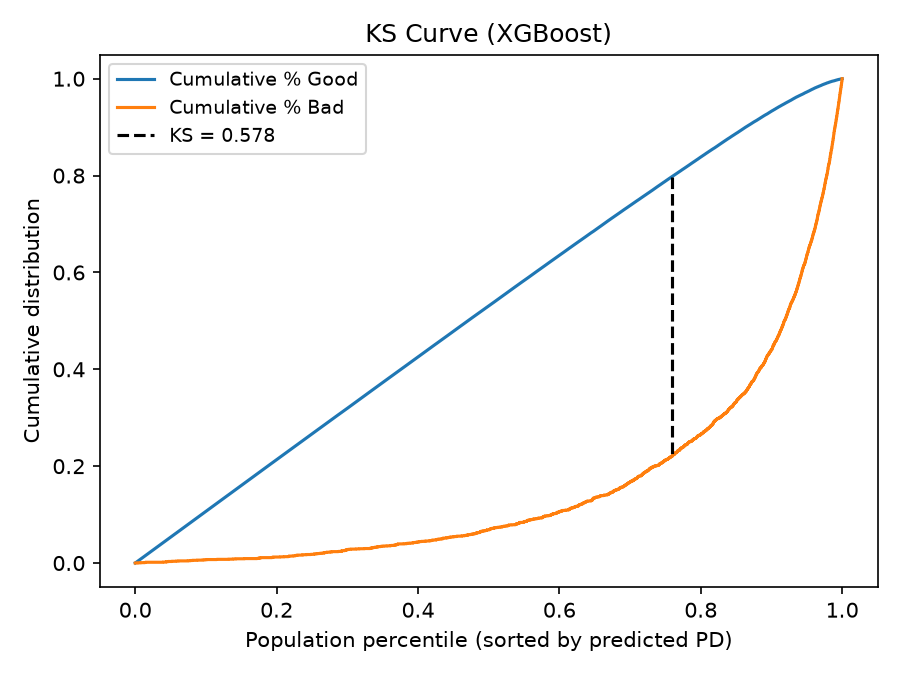

In [13]:
Image("../reports/figures/ks_curve.png")

**KS ≈ 0.58** is the maximum gap between the cumulative "good" and "bad" distributions across the score range. In credit risk, a KS above 0.4 is usually considered good and above 0.5 very good.

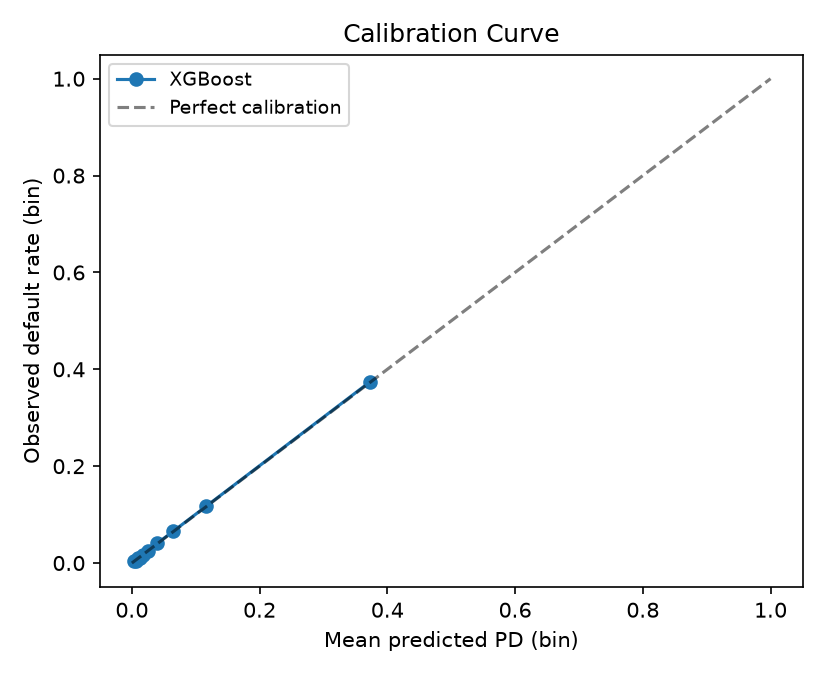

In [14]:
Image("../reports/figures/calibration.png")

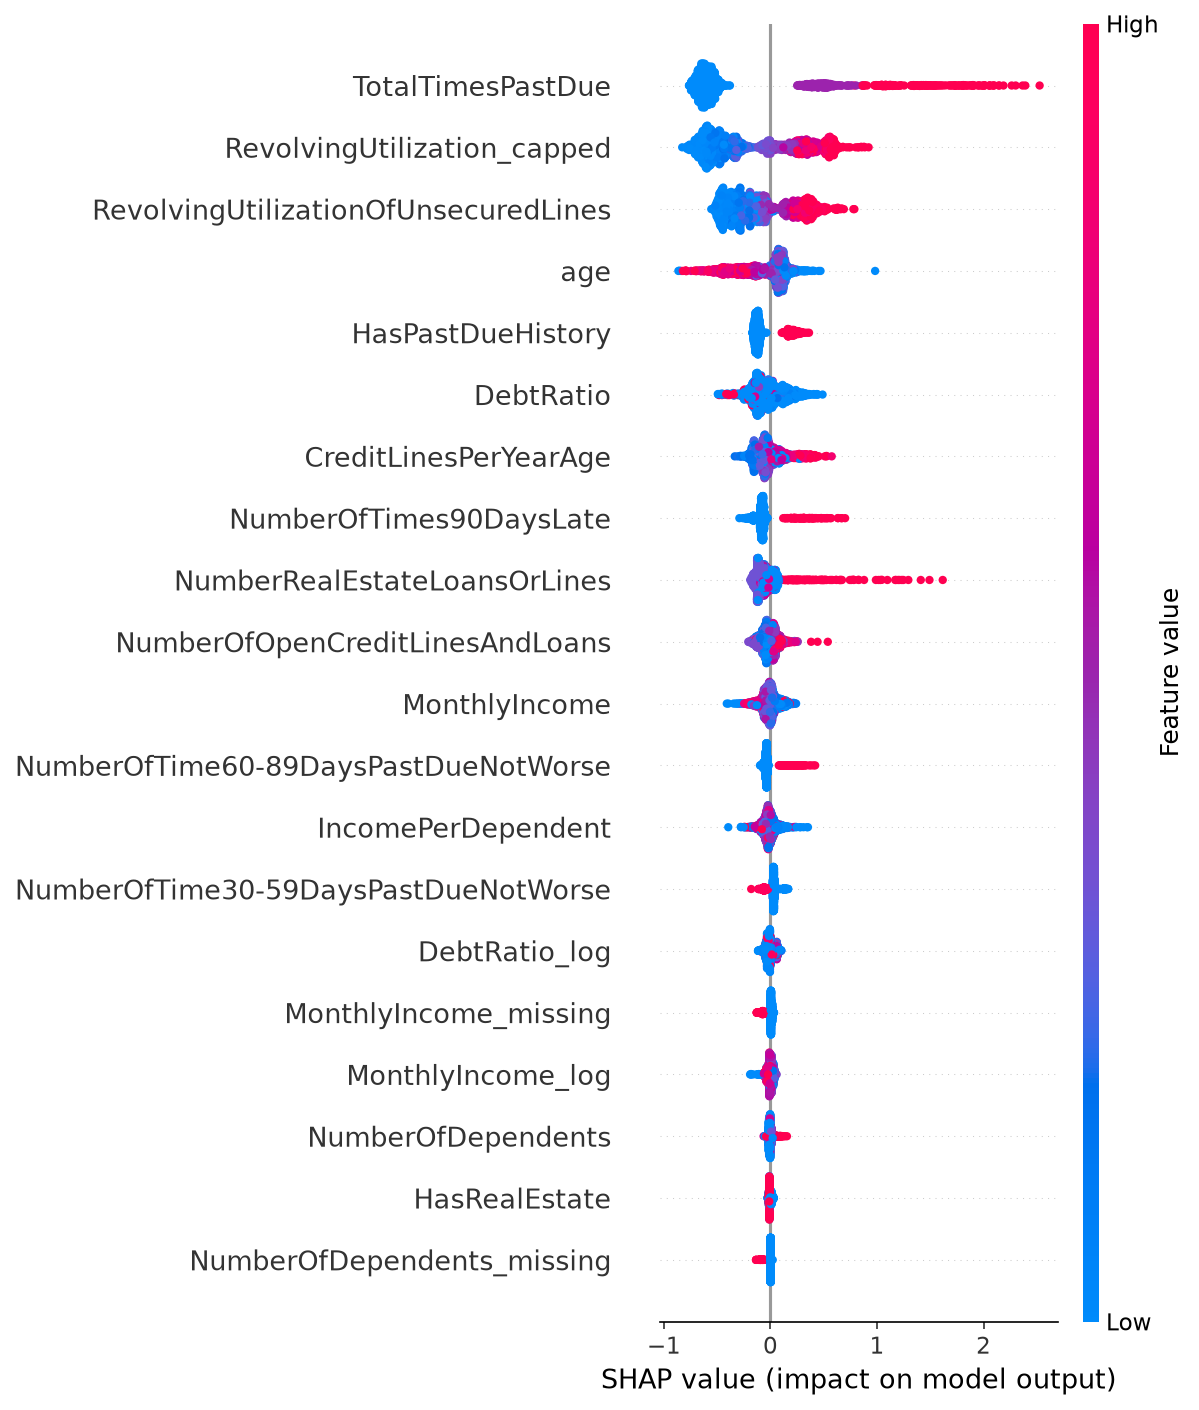

In [15]:
Image("../reports/figures/shap_summary.png")

SHAP agrees with the EDA: prior delinquency and revolving utilization drive most predictions, followed by age and debt ratio. That lines up with standard credit intuition, which is a useful check that the model hasn't latched onto something spurious.

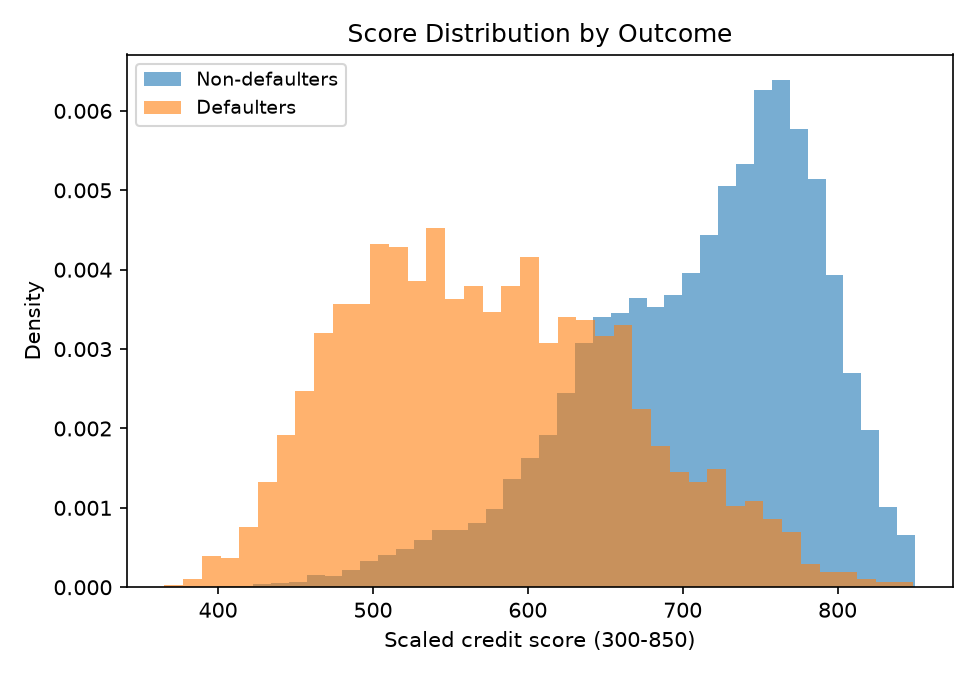

In [16]:
Image("../reports/figures/score_distribution.png")

## 5. From probability to score

Probabilities are converted to a 300-850 score with the points-to-double-the-odds transform used by commercial scorecards (`src/scorecard.py`): 720 points at 50:1 odds, and every 40 points doubles the odds. Defaulters and non-defaulters separate clearly across the score range above, which is what makes the score usable for cutoff rules (auto-approve above X, manual review between Y and X, decline below Y).

## 6. Business takeaway

In [17]:
from IPython.display import Markdown
capture = metrics["xgboost"]["top_decile_capture_rate"]
Markdown(
    f"Targeting the riskiest **10%** of applicants by predicted score catches "
    f"**{capture:.0%}** of actual defaults in the test set. A team using "
    f"this model to flag applications for manual review would catch over half of "
    f"future defaults by reviewing one application in ten."
)

Targeting the riskiest **10%** of applicants by predicted score catches **56%** of actual defaults in the test set. A team using this model to flag applications for manual review would catch over half of future defaults by reviewing one application in ten.